<a href="https://colab.research.google.com/github/Dharshini13002/Machine-learning-codes/blob/main/CA2_7010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RANDOM FOREST CLASSIFICATION FOR MOBILE GAME CUSTOMER PREDCITION FOR ADDICTED TO GAMES OR NOT


In [17]:
#Step 1: importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
# Step 2: Load dataset
df = pd.read_excel("/content/drive/MyDrive/CA-7010/Copy of Mobile_Games.xlsx")
print(df.head())

  Name     Age GENDER Daily I use to play Mobile games  \
0    A   10-15      M                            agree   
1    B   16-25      F                          netural   
2    C   26-35      M                            agree   
3    D   36-45      M                   strongly agree   
4    E   46-50      F                            agree   

  Daily 2 to 4 hrs I play I use to play Mobile games to have fun  \
0          strongly agree                         strongly agree   
1                   agree                                  agree   
2                   agree                                  agree   
3                   agree                         strongly agree   
4                   agree                                  agree   

  I use to play Mobile games to kill my time  \
0                         strongly dis agree   
1                             strongly agree   
2                             strongly agree   
3                         strongly dis agree   
4 

In [20]:
# Step 3: Preprocess data

# Handle categorical features using one-hot encoding
df_processed = pd.get_dummies(df.drop(columns=['Name', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14']), columns=['Age', 'GENDER', 'Daily I use to play Mobile games', 'Daily 2 to 4 hrs I play', 'I use to play Mobile games to have fun', 'I use to play Mobile games to kill my time', 'I use to play Mobile games to escape real world', 'I use to play Mobile games for strees relif', 'I use to play Mobile games for Competition', 'What are your favourite game genres?'], drop_first=True)

# Separate features (X) and target (y)
X = df_processed.drop('Addicted', axis=1)
y = df_processed['Addicted']

# Convert target variable to numerical (0 for 'no', 1 for 'yes')
y = y.apply(lambda x: 1 if x == 'yes' else 0)

print("Processed Data Sample:\n", X.head())
print("\nTarget Variable Sample:\n", y.head())

Processed Data Sample:
    Age_16-25  Age_26-35  Age_36-45  Age_46-50  Age_51-55  Age_56-60  \
0      False      False      False      False      False      False   
1       True      False      False      False      False      False   
2      False       True      False      False      False      False   
3      False      False       True      False      False      False   
4      False      False      False       True      False      False   

   Age_61-65  GENDER_M  Daily I use to play Mobile games_netural  \
0      False      True                                     False   
1      False     False                                      True   
2      False      True                                     False   
3      False      True                                     False   
4      False     False                                     False   

   Daily I use to play Mobile games_strongly agree  ...  \
0                                            False  ...   
1                     

In [22]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# Step 5: Build Random Forest Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
# Step 6: Predictions
y_pred = rf.predict(X_test)

In [26]:
# Step 7: Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['no', 'yes']))


Accuracy: 0.875

Confusion Matrix:
 [[4 0]
 [1 3]]

Classification Report:
               precision    recall  f1-score   support

          no       0.80      1.00      0.89         4
         yes       1.00      0.75      0.86         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



customer data prediction for whether they are addicted to mobile games or not

In [31]:
# Step : 8 Predict for a new customer for Not addcited customer

sample_new_customer = X_test.iloc[0].copy() # Using the first row of the test set as an example
sample_new_customer = sample_new_customer.values.reshape(1, -1) # Reshape for prediction

# Predict the addiction status for the new customer
prediction = rf.predict(sample_new_customer)

# Display the prediction
if prediction[0] == 0:
    print("Prediction for the new customer: Addicted (Yes)")
else:
    print("Prediction for the new customer: Not Addicted (No)")

Prediction for the new customer: Not Addicted (No)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [33]:
# Step : 9 Predict for a new customer if they are addicted

sample_new_customer = X_test.iloc[0].copy() # Using the first row of the test set as an example
sample_new_customer = sample_new_customer.values.reshape(1, -1) # Reshape for prediction

# Predict the addiction status for the new customer
prediction = rf.predict(sample_new_customer)

# Display the prediction
if prediction[0] == 1:
    print("Prediction for the new customer: Addicted (Yes)")
else:
    print("Prediction for the new customer: Not Addicted (No)")

Prediction for the new customer: Addicted (Yes)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


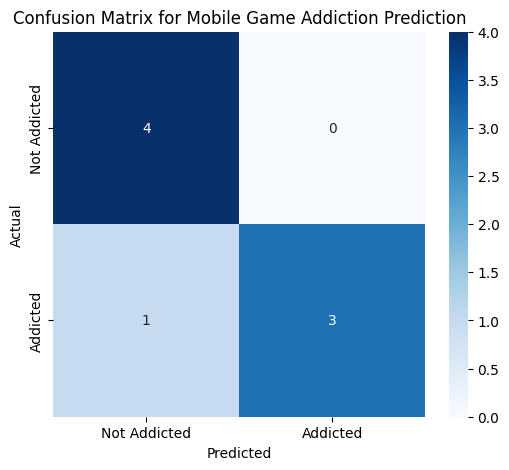

In [35]:
# Step 10: Visualize Confusion Matrix
import seaborn as sns # Import seaborn

# Get the confusion matrix from the evaluation step
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
xticklabels=["Not Addicted", "Addicted"],
yticklabels=["Not Addicted", "Addicted"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Mobile Game Addiction Prediction")
plt.show()

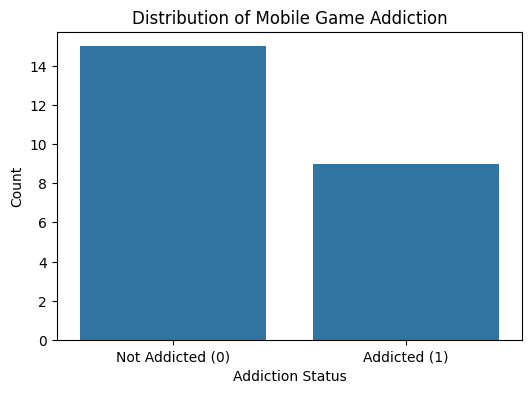

In [37]:
6# Step 11: Visualize the distribution of the target variable (Addicted)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.xticks([0, 1], ['Not Addicted (0)', 'Addicted (1)'])
plt.title('Distribution of Mobile Game Addiction')
plt.xlabel('Addiction Status')
plt.ylabel('Count')
plt.show()

In [39]:
# Step 12: Prepare a new customer record for prediction

new_customer_raw_data = {
    'Name': 'New Customer',
    'Age': '16-25',
    'GENDER': 'F',
    'Daily I use to play Mobile games': 'agree',
    'Daily 2 to 4 hrs I play': 'agree',
    'I use to play Mobile games to have fun': 'strongly agree',
    'I use to play Mobile games to kill my time': 'netural',
    'I use to play Mobile games to escape real world': 'agree',
    'I use to play Mobile games for strees relif': 'disagree',
    'I use to play Mobile games for Competition': 'agree',
    'What are your favourite game genres?': 'Adventure',
    'Unnamed: 11': np.nan, #for unused columns
    'Unnamed: 12': np.nan,
    'Unnamed: 13': np.nan,
    'Unnamed: 14': np.nan,
    'Addicted': 'no'
}


new_customer_df = pd.DataFrame([new_customer_raw_data])

new_customer_processed = pd.get_dummies(new_customer_df.drop(columns=['Name', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Addicted']), columns=['Age', 'GENDER', 'Daily I use to play Mobile games', 'Daily 2 to 4 hrs I play', 'I use to play Mobile games to have fun', 'I use to play Mobile games to kill my time', 'I use to play Mobile games to escape real world', 'I use to play Mobile games for strees relif', 'I use to play Mobile games for Competition', 'What are your favourite game genres?'], drop_first=True)

new_customer_aligned = new_customer_processed.reindex(columns=X.columns, fill_value=0)

print("Prepared new customer data for prediction:\n", new_customer_aligned)



Prepared new customer data for prediction:
    Unnamed: 11  Unnamed: 12  Unnamed: 13  Unnamed: 14  Name_A  Name_B  Name_C  \
0            0            0            0            0       0       0       0   

   Name_D  Name_E  Name_F  ...  \
0       0       0       0  ...   

   What are your favourite game genres?_Fighting, Racin  \
0                                                  0      

   What are your favourite game genres?_Fighting, Racing  \
0                                                  0       

   What are your favourite game genres?_Puzzle  \
0                                            0   

   What are your favourite game genres?_Puzzle, Fighting  \
0                                                  0       

   What are your favourite game genres?_Puzzle, Fighting, Racin  \
0                                                  0              

   What are your favourite game genres?_Sports,  Fighting, Racing  \
0                                                  0      

In [41]:
# Step 13: Make prediction for the new customer

# Use the trained Random Forest model to predict on the prepared new customer data
new_customer_prediction = rf.predict(new_customer_aligned)

# Display the prediction
if new_customer_prediction[0] == 1:
    print("Prediction for the new customer: Addicted (Yes)")
else:
    print("Prediction for the new customer: Not Addicted (No)")

Prediction for the new customer: Not Addicted (No)
